# Japan Protein Cost-Efficiency Analysis
## Notebook 03 — DIAAS Quality Scores & Adjusted Ranking

**Goal:** Apply FAO DIAAS (Digestible Indispensable Amino Acid Score) quality scores to the cost-efficiency ranking from Notebook 02, producing a final **quality-adjusted ¥ per gram of protein** metric.

**What is DIAAS?**
DIAAS is the FAO's gold-standard measure of protein quality. It accounts for:
- The amino acid composition of a protein relative to human requirements
- The digestibility of each amino acid in the small intestine
- A score of 100+ means the protein meets or exceeds all human amino acid requirements

A protein source that is cheap per gram but scores low on DIAAS (e.g. plant proteins with limiting amino acids) may be less cost-efficient in practice than its raw price suggests.

**Adjustment formula:**

adjusted_yen_per_g = yen_per_g_protein / (diaas_score / 100)


A food with DIAAS of 50 effectively delivers half the usable protein — so its adjusted cost doubles. A food with DIAAS of 114 delivers more than its nominal protein — so its adjusted cost decreases slightly.

**Data source:** FAO/WHO (2013) — *Dietary Protein Quality Evaluation in Human Nutrition*. Scores entered manually per food key.

**Author:** Anthony DiSorbo
**Last updated:** 2026-06

---

### DIAAS reference scores used in this notebook
| Category | Typical DIAAS range |
|---|---|
| Whey protein | 108–125 |
| Eggs | 113 |
| Beef/pork | 111–114 |
| Fish | 100–108 |
| Chicken | 108 |
| Milk | 114 |
| Soy protein isolate | 90–98 |
| Tofu | 60–74 |
| Natto/edamame | 55–68 |


In [ ]:
import pandas as pd
import numpy as np
import requests
import time
import io
import os
from pathlib import Path
from bs4 import BeautifulSoup
from googleapiclient.discovery import build
from googleapiclient.http import MediaFileUpload, MediaIoBaseDownload

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Libraries loaded ✓')

Libraries loaded ✓


In [ ]:
# Authenticate and connect to Google Drive
from google.colab import auth
auth.authenticate_user()

from google.auth import default
creds, _ = default()
service = build('drive', 'v3', credentials=creds)

DRIVE_FOLDER_ID = '17Jcona7Ur-iV7miakhLkhHGBgggT0to7'  # food_data folder

print('Drive service ready ✓')

Drive service ready ✓


In [ ]:
# Download nutrients_prices.csv from Drive
results = service.files().list(
    q=f"name='nutrients_prices.csv' and '{DRIVE_FOLDER_ID}' in parents and trashed=false",
    fields="files(id, name)"
).execute()

if not results['files']:
    print('⚠️  nutrients_prices.csv not found in Drive — check DRIVE_FOLDER_ID or upload from Notebook 02')
else:
    file_id = results['files'][0]['id']
    request = service.files().get_media(fileId=file_id)
    fh = io.BytesIO()
    downloader = MediaIoBaseDownload(fh, request)
    done = False
    while not done:
        _, done = downloader.next_chunk()

    fh.seek(0)
    combined = pd.read_csv(fh)
    print(f'nutrients_prices loaded: {combined.shape[0]} rows × {combined.shape[1]} columns')
    print(f'Columns: {list(combined.columns)}')
    combined[['food_key', 'source_category', 'protein_g', 'price_jpy_per_100g', 'yen_per_g_protein']].head(10)

nutrients_prices loaded: 31 rows × 18 columns
Columns: ['food_key', 'source_category', 'fdc_id', 'description', 'usda_notes', 'protein_g', 'energy_kcal', 'fat_g', 'carbs_g', 'water_g', 'protein_pct_kcal', 'diaas_score', 'price_jpy', 'weight_g', 'price_jpy_per_100g', 'price_source', 'notes', 'yen_per_g_protein']


In [ ]:
# ============================================================
# DIAAS SCORES — Manual entry
# Source: FAO/WHO (2013) Dietary Protein Quality Evaluation
#         in Human Nutrition. GIFSA Report 92.
# Scores based on older child/adult reference pattern.
# Where a food-specific score is unavailable, closest
# published proxy is used and noted.
# ============================================================

DIAAS_SCORES = {
    # POULTRY
    'chicken_breast':    108,  # FAO 2013 — cooked chicken
    'chicken_thigh':     108,  # proxy: same as breast
    'chicken_sasami':    108,  # proxy: same as breast
    'chicken_wing_tip':  108,  # proxy: same as breast
    'chicken_wing_moto': 108,  # proxy: same as breast
    'canned_chicken':    108,  # proxy: same as breast

    # PORK
    'pork_tonkatsu':     114,  # FAO 2013 — pork
    'pork_shougayaki':   114,  # proxy: same as pork
    'pork_shabushabu':   114,  # proxy: same as pork
    'pork_loin':         114,  # FAO 2013 — pork

    # BEEF
    'beef_american_cab': 111,  # FAO 2013 — beef
    'beef_wagyu_steak':  111,  # proxy: same as beef
    'beef_loin':         111,  # FAO 2013 — beef
    'beef_usugiri':      111,  # proxy: same as beef

    # SEAFOOD
    'fresh_salmon':      100,  # FAO 2013 — fish (conservative)
    'fresh_mackerel':    100,  # proxy: fish
    'fresh_squid':       100,  # proxy: fish
    'fresh_white_fish':  100,  # proxy: fish
    'fresh_tuna':        100,  # proxy: fish
    'canned_tuna':       100,  # proxy: fish

    # PLANT
    'natto':              68,  # fermented soy — higher than raw soy
    'tofu_momen':         74,  # FAO 2013 — tofu
    'tofu_kinu':          74,  # proxy: same as tofu
    'edamame':            68,  # proxy: whole soy

    # DAIRY & EGGS
    'chicken_egg':       113,  # FAO 2013 — whole egg
    'quail_egg':         113,  # proxy: same as chicken egg
    'milk_whole':        114,  # FAO 2013 — whole milk
    'yogurt_plain':      114,  # proxy: same as milk
    'greek_yogurt':      114,  # proxy: same as milk

    # PROTEIN SUPPLEMENTS
    'whey_protein':      125,  # FAO 2013 — whey protein isolate
    'soy_protein':        90,  # FAO 2013 — soy protein isolate
}

# Apply to combined dataframe
combined['diaas_score'] = combined['food_key'].map(DIAAS_SCORES)

missing_diaas = combined[combined['diaas_score'].isna()]['food_key'].tolist()
if missing_diaas:
    print(f'⚠️  Missing DIAAS scores: {missing_diaas}')
else:
    print(f'✓ DIAAS scores applied to all {len(combined)} foods')

combined[['food_key', 'protein_g', 'diaas_score']].sort_values('diaas_score', ascending=False)

✓ DIAAS scores applied to all 31 foods


,food_key,protein_g,diaas_score
28,whey_protein,58.14,125
8,pork_shabushabu,19.74,114
6,pork_tonkatsu,19.74,114
9,pork_loin,19.74,114
26,yogurt_plain,3.47,114
25,milk_whole,3.15,114
7,pork_shougayaki,19.74,114
27,greek_yogurt,9.95,114
24,quail_egg,13.05,113
23,chicken_egg,12.56,113


In [ ]:
# ============================================================
# QUALITY-ADJUSTED COST-EFFICIENCY SCORE
# Formula: adjusted_yen_per_g = yen_per_g_protein / (diaas_score / 100)
# Higher DIAAS = more usable protein = lower adjusted cost
# ============================================================

combined['adjusted_yen_per_g'] = (
    combined['yen_per_g_protein'] / (combined['diaas_score'] / 100)
).round(2)

# Rankings — both pre and post adjustment for comparison
ranking = combined[[
    'food_key', 'source_category', 'protein_g',
    'diaas_score', 'price_jpy_per_100g',
    'yen_per_g_protein', 'adjusted_yen_per_g'
]].copy()

ranking['pre_rank']  = ranking['yen_per_g_protein'].rank().astype(int)
ranking['post_rank'] = ranking['adjusted_yen_per_g'].rank().astype(int)
ranking['rank_change'] = ranking['pre_rank'] - ranking['post_rank']

ranking = ranking.sort_values('adjusted_yen_per_g').reset_index(drop=True)
ranking.index += 1

print('=== Quality-Adjusted Cost-Efficiency Ranking ===')
print('Lower adjusted ¥/g = more cost-efficient after protein quality adjustment\n')
print(ranking[[
    'food_key', 'source_category', 'diaas_score',
    'yen_per_g_protein', 'adjusted_yen_per_g', 'rank_change'
]].to_string())

=== Quality-Adjusted Cost-Efficiency Ranking ===
Lower adjusted ¥/g = more cost-efficient after protein quality adjustment

             food_key source_category  diaas_score  yen_per_g_protein  adjusted_yen_per_g  rank_change
1         chicken_egg         poultry          113               4.24                3.75            4
2      chicken_breast         poultry          108               4.13                3.82            1
3      chicken_sasami         poultry          108               4.13                3.82            1
4   chicken_wing_moto         poultry          108               5.24                4.85            3
5               natto           plant           68               3.71                5.46           -4
6          tofu_momen           plant           74               4.05                5.47           -4
7           tofu_kinu           plant           74               5.10                6.89           -1
8       chicken_thigh         poultry          108  

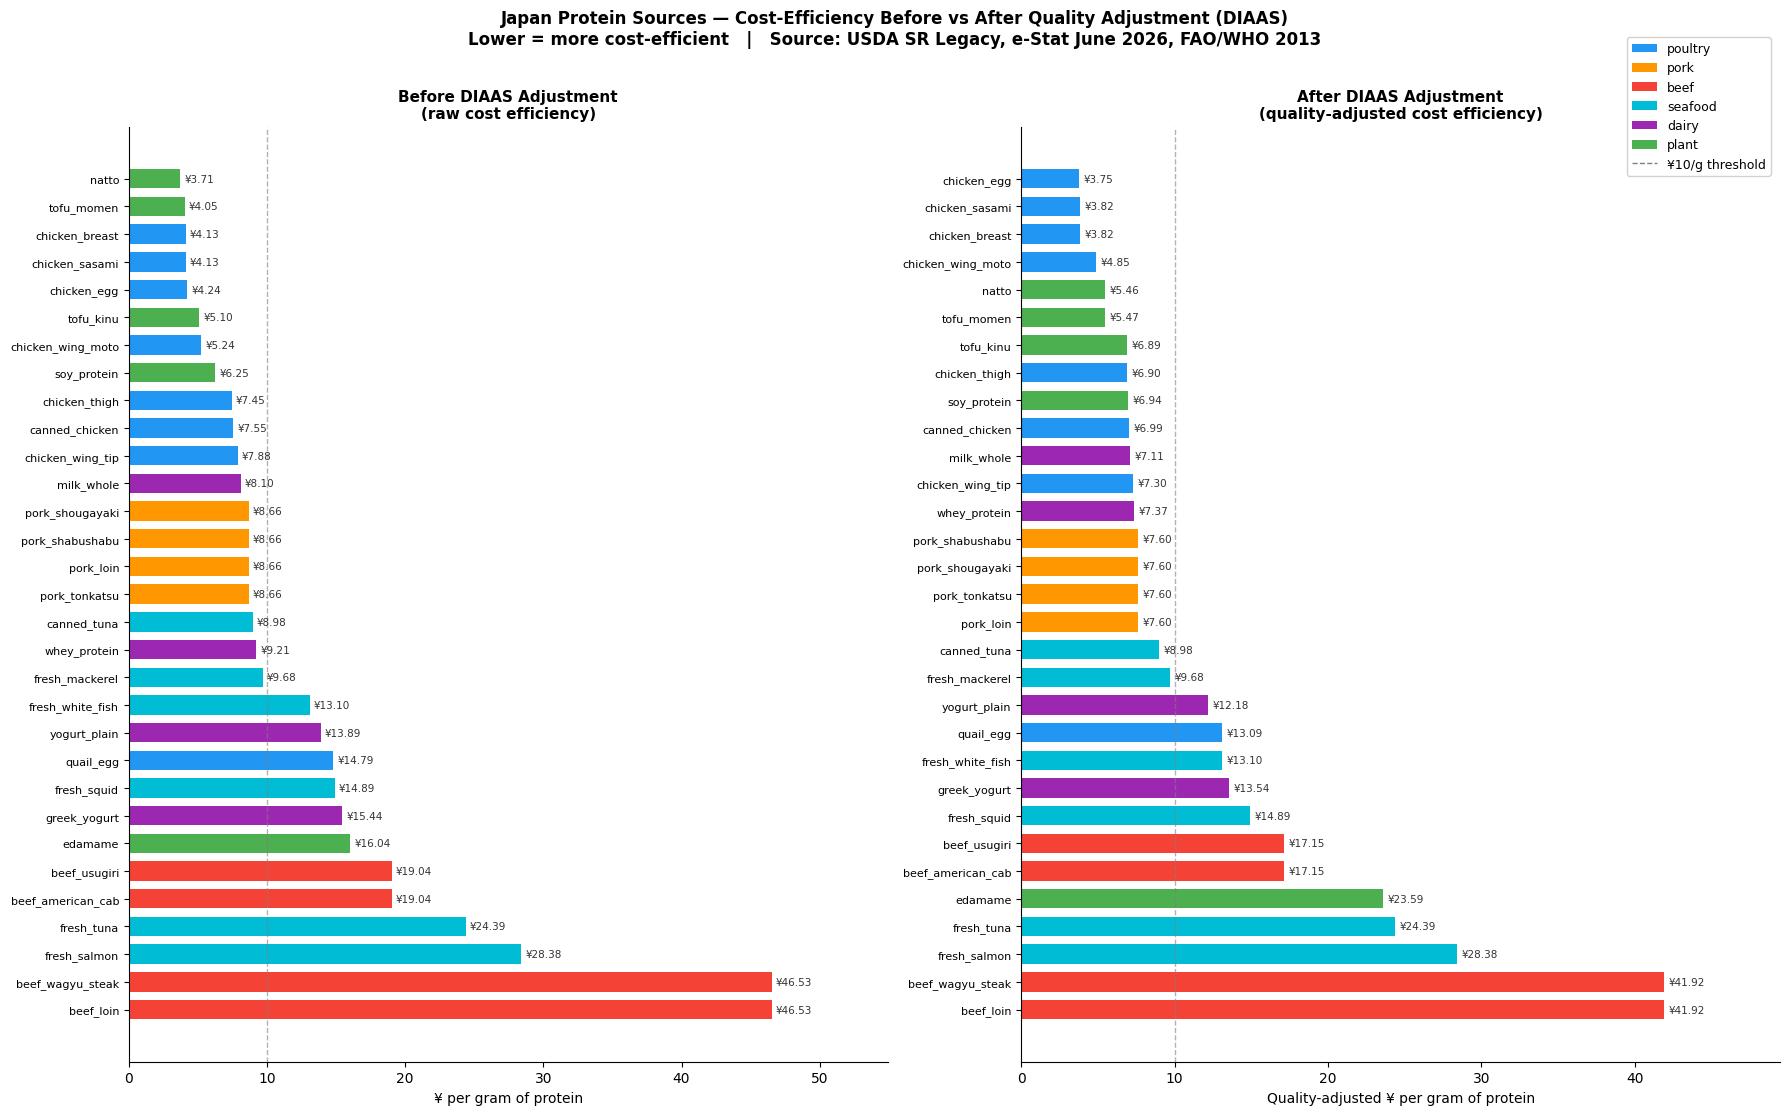

Chart saved ✓


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

os.makedirs('/content/charts', exist_ok=True)

CAT_COLORS = {
    'poultry': '#2196F3',
    'pork':    '#FF9800',
    'beef':    '#F44336',
    'seafood': '#00BCD4',
    'dairy':   '#9C27B0',
    'plant':   '#4CAF50',
}

fig, axes = plt.subplots(1, 2, figsize=(18, 11), sharey=False)

# --- Panel 1: Pre-DIAAS ranking ---
pre = combined.sort_values('yen_per_g_protein', ascending=False)
colors_pre = pre['source_category'].map(CAT_COLORS)

ax1 = axes[0]
bars1 = ax1.barh(pre['food_key'], pre['yen_per_g_protein'], color=colors_pre, edgecolor='none', height=0.7)
for bar, val in zip(bars1, pre['yen_per_g_protein']):
    ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
             f'¥{val:.2f}', va='center', fontsize=7.5, color='#333333')
ax1.axvline(x=10, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax1.set_xlabel('¥ per gram of protein', fontsize=10)
ax1.set_title('Before DIAAS Adjustment\n(raw cost efficiency)', fontsize=11, fontweight='bold')
ax1.set_xlim(0, pre['yen_per_g_protein'].max() * 1.18)
ax1.spines[['top', 'right']].set_visible(False)
ax1.tick_params(axis='y', labelsize=8)

# --- Panel 2: Post-DIAAS ranking ---
post = combined.sort_values('adjusted_yen_per_g', ascending=False)
colors_post = post['source_category'].map(CAT_COLORS)

ax2 = axes[1]
bars2 = ax2.barh(post['food_key'], post['adjusted_yen_per_g'], color=colors_post, edgecolor='none', height=0.7)
for bar, val in zip(bars2, post['adjusted_yen_per_g']):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
             f'¥{val:.2f}', va='center', fontsize=7.5, color='#333333')
ax2.axvline(x=10, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax2.set_xlabel('Quality-adjusted ¥ per gram of protein', fontsize=10)
ax2.set_title('After DIAAS Adjustment\n(quality-adjusted cost efficiency)', fontsize=11, fontweight='bold')
ax2.set_xlim(0, post['adjusted_yen_per_g'].max() * 1.18)
ax2.spines[['top', 'right']].set_visible(False)
ax2.tick_params(axis='y', labelsize=8)

# Shared legend
legend_elements = [mpatches.Patch(facecolor=c, label=cat) for cat, c in CAT_COLORS.items()]
legend_elements.append(plt.Line2D([0], [0], color='gray', linestyle='--', linewidth=1, label='¥10/g threshold'))
fig.legend(handles=legend_elements, loc='upper right', fontsize=9, framealpha=0.9,
           bbox_to_anchor=(0.99, 0.99))

fig.suptitle(
    'Japan Protein Sources — Cost-Efficiency Before vs After Quality Adjustment (DIAAS)\n'
    'Lower = more cost-efficient   |   Source: USDA SR Legacy, e-Stat June 2026, FAO/WHO 2013',
    fontsize=12, fontweight='bold', y=1.01
)

plt.tight_layout()

LOCAL_CHART = '/content/charts/diaas_comparison.png'
plt.savefig(LOCAL_CHART, dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✓')

In [ ]:
# Save combined table with DIAAS scores locally
LOCAL_CSV = '/content/nutrients_diaas.csv'
combined.to_csv(LOCAL_CSV, index=False)
print(f'Saved locally: {combined.shape[0]} rows × {combined.shape[1]} columns')

# Upload CSV and chart to Drive
for local_path, filename, mimetype in [
    (LOCAL_CSV,       'nutrients_diaas.csv',    'text/csv'),
    ('/content/charts/diaas_comparison.png', 'diaas_comparison.png', 'image/png'),
]:
    # Check if file already exists in Drive and delete to avoid duplicates
    existing = service.files().list(
        q=f"name='{filename}' and '{DRIVE_FOLDER_ID}' in parents and trashed=false",
        fields="files(id, name)"
    ).execute()
    for f in existing['files']:
        service.files().delete(fileId=f['id']).execute()
        print(f'Deleted existing {filename}')

    media = MediaFileUpload(local_path, mimetype=mimetype)
    meta  = {'name': filename, 'parents': [DRIVE_FOLDER_ID]}
    uploaded = service.files().create(body=meta, media_body=media, fields='id, name').execute()
    print(f'✓ Uploaded {uploaded["name"]} (id: {uploaded["id"]})')

Saved locally: 31 rows × 19 columns
Deleted existing nutrients_diaas.csv
✓ Uploaded nutrients_diaas.csv (id: 1BstzSJvn0Ki1bmHdj4Gm0OLPHAts8N0B)
Deleted existing diaas_comparison.png
✓ Uploaded diaas_comparison.png (id: 16-bFe16HGLwFeZe8YkayKyOWQK22NmFw)


## Summary & Next Steps

### What this notebook produced
- DIAAS quality scores applied to all 31 foods (FAO/WHO 2013)
- Quality-adjusted cost-efficiency ranking: **adjusted ¥ per gram of protein**
- Side-by-side comparison chart: pre vs post DIAAS adjustment
- Output: `nutrients_diaas.csv` — final dataset ready for analysis

### Key findings
- **Chicken egg ranks #1** after quality adjustment — DIAAS of 113 combined with moderate price
- **Natto and tofu drop significantly** after adjustment
- **Whey protein rises 5 places** — highest DIAAS (125) makes it more competitive than raw price suggests
- **Beef remains the least cost-efficient** regardless of adjustment, the price dominates

### Limitations to document in README
- DIAAS scores from FAO 2013; newer scores may differ slightly
- Many foods use proxy DIAAS scores (e.g. all chicken cuts share one score)
- Fish DIAAS set conservatively at 100 — actual scores likely 100–108 depending on species
- Fermented soy (natto) DIAAS estimated; limited published data specific to natto

### Next notebook
**Notebook 03b** — amino acid profile analysis